In [3]:
# Importing the libraries
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [4]:
df = pd.read_csv ("sa_healthcare_big_messy.csv")

In [5]:
# Checking the initial rows and columns
df.shape

(5030, 7)

In [6]:
# Checking the data types for the rows.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5030 non-null   int64  
 1   sex       5030 non-null   object 
 2   bmi       4778 non-null   float64
 3   children  5030 non-null   int64  
 4   smoker    5030 non-null   object 
 5   region    5030 non-null   object 
 6   charges   5030 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 275.2+ KB


In [7]:
# Displaying the total number of null values on BMI
df["bmi"].isnull().sum()

np.int64(252)

In [8]:
# Checking the total number of duplicated rows
df.duplicated().sum()

np.int64(3284)

In [9]:
# Removing the duplicated rows
df = df.drop_duplicates()

In [10]:
# Verifying if there're still rows that are duplicated
df.duplicated().sum()

np.int64(0)

In [11]:
# Display the dataframe shape to verify that the number of rows decreased after removing duplicates
df.shape

(1746, 7)

In [12]:
# Checking ow messy are the regions
df["region"].unique()

array(['Western Cape', 'Eastern Cape', 'KwaZulu-Natal', 'GAUTENG',
       'Gauteng', 'gauteng'], dtype=object)

In [13]:
# Remove formatting issue of region and convert to lower cases
df["region"] = df["region"].str.strip().str.lower()

In [14]:
# Remove formatting issue of sex and convert to lower cases
df["sex"] = df["sex"].str.strip().str.lower()

In [15]:
# Verifying the above commands if the took effect
df["region"].unique()

array(['western cape', 'eastern cape', 'kwazulu-natal', 'gauteng'],
      dtype=object)

In [16]:
df["sex"].unique()

array(['male', 'female'], dtype=object)

In [17]:
# Checking the sum of the impossible ages where 0 <= age >= 100
((df["age"] < 0) | (df["age"] > 100)).sum()

np.int64(50)

In [18]:
# Removing the impossible ages from the dataset
df = df[(df["age"] > 0) & (df["age"] < 100)]

In [19]:
# Checking why charges are incorrectly named as objects.
df["charges"]

0       R10,214.64
1       R46,113.51
2       R11,931.13
3        R8,582.30
4        R4,561.19
           ...    
4981     R7,281.51
4984     R9,174.14
4986    R10,407.09
4998     R2,134.90
4999     R1,880.49
Name: charges, Length: 1696, dtype: object

In [20]:
# Removing the 'R' and the ',' from the charges values
df["charges"] = df["charges"].str.replace("R", "").str.replace(",", "")

In [21]:
# Changing the charges datatype to be float
df["charges"] = df["charges"].astype(float)

In [22]:
# Verifying if the charges values has a correct datatype and are in the correct format.
df["charges"]

0       10214.64
1       46113.51
2       11931.13
3        8582.30
4        4561.19
          ...   
4981     7281.51
4984     9174.14
4986    10407.09
4998     2134.90
4999     1880.49
Name: charges, Length: 1696, dtype: float64

In [23]:
df.isnull().sum()

age           0
sex           0
bmi         229
children      0
smoker        0
region        0
charges       0
dtype: int64

In [24]:
# Fill missing BMI values using the median BMI calculated separately for each sex group
df["bmi"] = df["bmi"].fillna(df.groupby('sex')['bmi'].transform('median'))

In [25]:
# Verifying if the are no null values present
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
# Verifying the columns that needs to be encoded
df.select_dtypes(include="object").columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [27]:
# Checking the number of columns before encoding
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [28]:
# To create a snapshot of the original column before running the encoding
df_eda = df.copy()

In [29]:
# Convert categorical variables (sex, smoker, region) into numerical features using One-Hot Encoding
df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

In [30]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1696 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1696 non-null   int64  
 1   sex       1696 non-null   object 
 2   bmi       1696 non-null   float64
 3   children  1696 non-null   int64  
 4   smoker    1696 non-null   object 
 5   region    1696 non-null   object 
 6   charges   1696 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 106.0+ KB


In [31]:
# Verifying if the One-Hot Encoding took place
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_gauteng,region_kwazulu-natal,region_western cape
0,55,29.900,0,10214.64,True,False,False,False,True
1,37,47.600,2,46113.51,False,True,False,False,True
2,58,25.175,0,11931.13,True,False,False,False,False
3,39,23.870,5,8582.30,False,False,False,True,False
4,18,31.350,4,4561.19,False,False,False,False,False


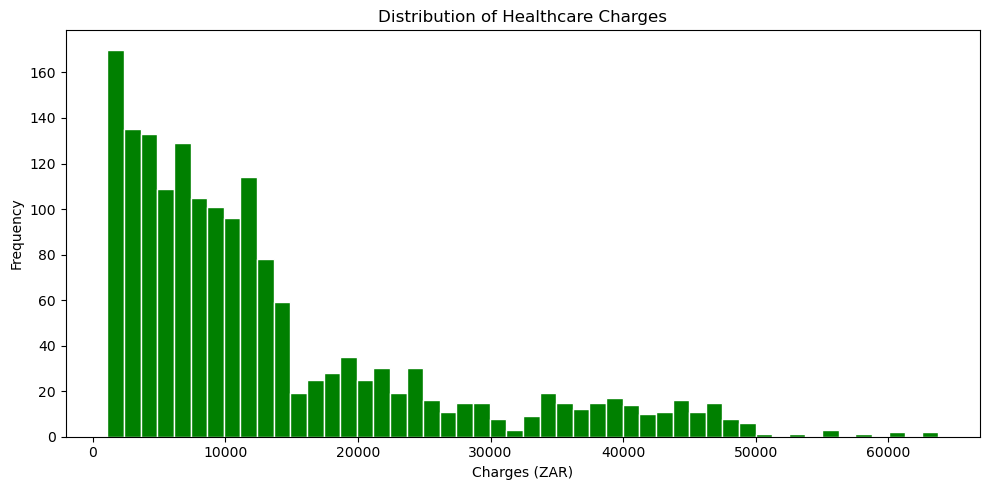

In [32]:
# The following code is for creating the Histogram
# The figure size is set to improve readability, and the data is divided into 50 bins to show how frequently charge values occur.
# Titles and axis labels are added to clearly describe the plot, while plt.show() renders the histogram.
# plt.tight_layout() is used to automatically adjust spacing so labels and titles are not cut off.

plt.figure(figsize=(10, 5))
plt.hist(df["charges"], bins=50, color="green", edgecolor="white")
plt.title("Distribution of Healthcare Charges")
plt.xlabel("Charges (ZAR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

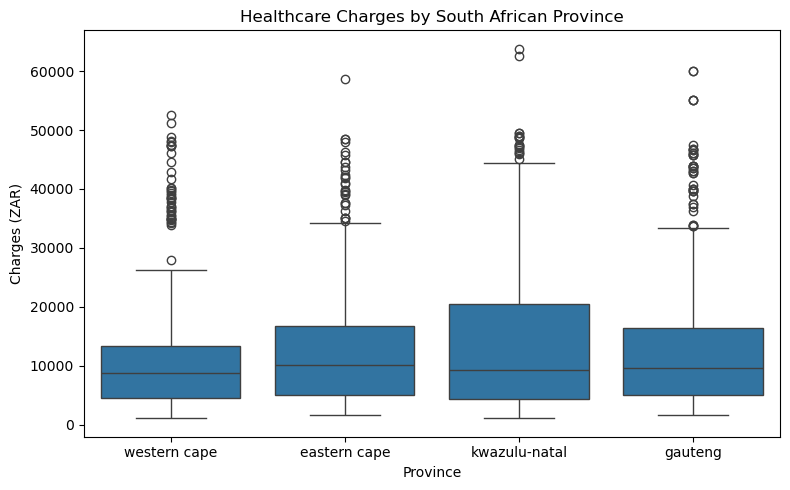

In [33]:
# Create a boxplot to compare the distribution of healthcare charges across South African provinces.
# The plot visualizes the median, spread (interquartile range), and potential outliers for charges in each region,
# helping identify differences in healthcare spending patterns between provinces.
plt.figure(figsize=(8, 5))
sn.boxplot(data=df_eda, x="region", y="charges")
plt.title("Healthcare Charges by South African Province")
plt.xlabel("Province")
plt.ylabel("Charges (ZAR)")
plt.tight_layout()
plt.show()

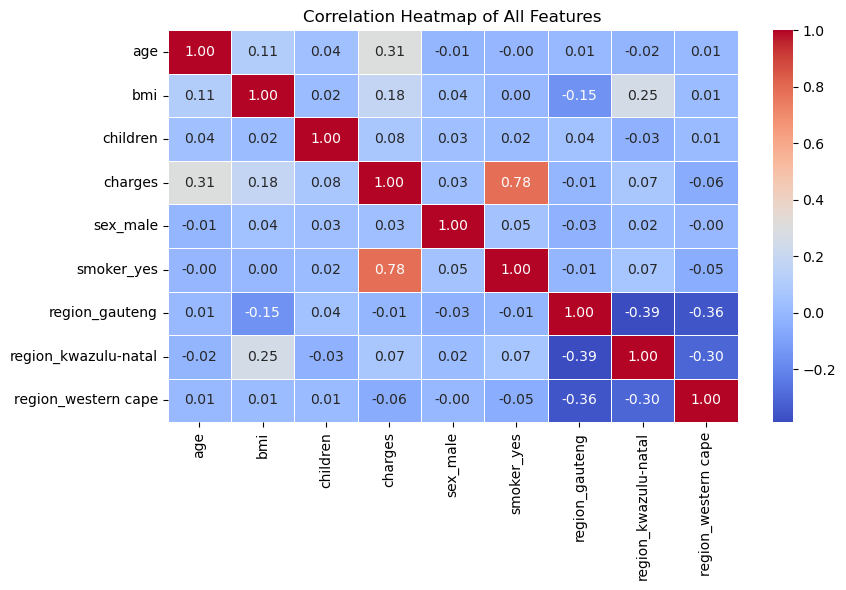

In [34]:
# Create a correlation heatmap to visualize the strength and direction of relationships between all numerical features in the dataset.
# The heatmap displays correlation coefficients inside each cell (annot=True), formatted to two decimal places, with colors indicating
# positive or negative relationships. This helps identify which variables are strongly related to healthcare charges or to each other.
plt.figure(figsize=(9, 6))
sn.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()

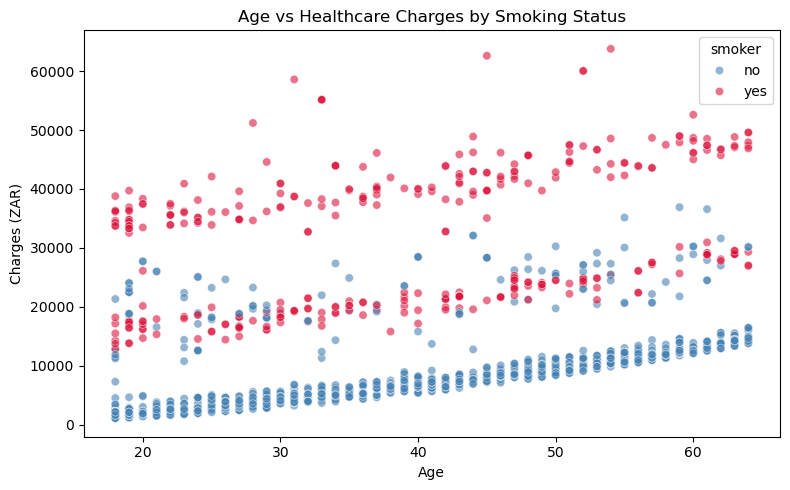

In [35]:
# Create a scatter plot to examine the relationship between age and healthcare charges.
# Points are color-coded by smoking status to highlight how smokers and non-smokers differ in medical costs.
# This visualization helps identify patterns, trends, and potential cost drivers such as age and smoking behavior.
plt.figure(figsize=(8, 5))
sn.scatterplot(data=df_eda, x="age", y="charges", hue="smoker",
               palette={"yes": "crimson", "no": "steelblue"}, alpha=0.6)
plt.title("Age vs Healthcare Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Charges (ZAR)")
plt.tight_layout()
plt.show()

In [36]:
# Define features (x) and labels(y)
x = df.drop("charges", axis=1) #everything except charges
y = df["charges"]
# Splitting into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#Verify the split
print(f"Training rows: {len(x_train)}")
print(f"Testing rows: {len(x_test)}")

Training rows: 1356
Testing rows: 340


In [37]:
# Train the model
linearR_model = LinearRegression()
linearR_model.fit(x_train, y_train)
# Make predictions on test set
linearR_predictions = linearR_model.predict(x_test)

In [38]:
# Calculate R2 score
linearR_r2 = r2_score(y_test, linearR_predictions)

# Calculate Root Mean Square Error
linearR_rmse = np.sqrt(mean_squared_error(y_test, linearR_predictions))

In [39]:
# Display results
print("      LINEAR REGRESSION RESULTS       ")
print(f"R2 Score:     {linearR_r2:.4f}")
print(f"Root Mean Square Error:     R{linearR_rmse:,.2f}")

      LINEAR REGRESSION RESULTS       
R2 Score:     0.7482
Root Mean Square Error:     R6,292.97


In [40]:
# Train the model
randomf_model = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_split=5, random_state=42)
randomf_model.fit(x_train, y_train)
# Make predictions on test set
randomf_predictions = randomf_model.predict(x_test)

In [41]:
# Calculate R2 Score
randomf_r2 = r2_score(y_test, randomf_predictions)

# Calculate RMSE
randomf_rmse = np.sqrt(mean_squared_error(y_test, randomf_predictions))

In [42]:
# Display results
print("     RANDOM FOREST RESULTS     ")
print(f"R2 Score:      {randomf_r2:.4f}")
print(f"Root Means Square Error:     R{randomf_rmse:,.2f}")

     RANDOM FOREST RESULTS     
R2 Score:      0.8316
Root Means Square Error:     R5,146.28


In [46]:
#Evaluation Matrix
# Comparing the Linear Regression and the Random Forest Regressor

print(f"Linear Regression: R2 = {r2_linearR:.4f}, RMSE = R{rmse_linearR:.2f}")
print(f"Random Forest: R2 = {r2_randomf:.4f}, RMSE = R{rmse_randomf:.2f}")

Linear Regression: R2 = 0.7482, RMSE = R6292.97
Random Forest: R2 = 0.8316, RMSE = R5146.28


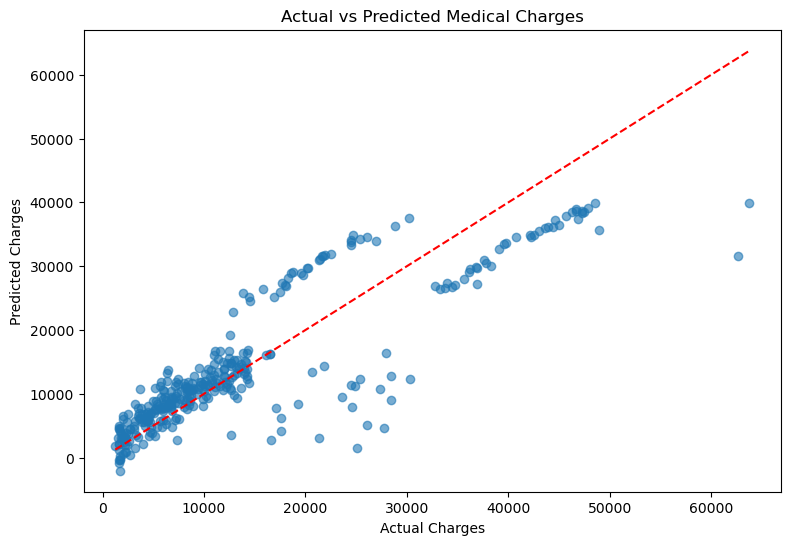

In [47]:
# Create a scatter plot comparing actual medical charges with predicted charges from the Linear Regression model
# The dashed red line represents perfect predictions (where predicted = actual)

plt.figure(figsize=(9,6))
plt.scatter(y_test, linearR_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Charges")
plt.show()